# BES Voter Panel — Labour switchers, third parties & dynamics

Consolidated analysis of the **BES combined internet panel** (v30.1 release, waves 1–30,
2014–2024; fieldwork of the latest wave W30 is May 2025). The source `.sav` lives at
`source_data/bes_voter_panel_internet_study/raw/` (stored as split zip parts) and is read
**once** below; every section reuses the same in-memory frame.

Sections:
1. **Profile of Labour→Green and Labour→Reform switchers** — defection snapshot, demographics, attitudes, region.
2. **Third-party squeeze** — does minor-party support fall at general elections?
3. **Switcher dynamics over time** — return-to-Labour flows, warmth-to-Labour trajectory, and disaffection-vs-culture gaps.
4. **Switchers vs the national average** — demographics + current vote intention, and Labour vote history with a chart.

Cohorts (used throughout): **GE2024 Labour voters**, split by their **W30 (May 2025) vote intention** into
*Loyalist* (still Labour), *→Green*, and *→Reform*. Weighted by `wt_new_W30`. Attitude scales are cleaned of the
`9999` "Don't know" code. Outputs (CSVs + the chart) are written next to this notebook.

## Setup — paths, constants, helpers, and a single read of the panel

In [1]:
%matplotlib inline
import datetime as _dt
import shutil, tempfile, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadstat

# This notebook has no __file__; locate the repo root by walking up to source_data.
def find_repo(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "source_data" / "bes_voter_panel_internet_study").exists():
            return p
        p = p.parent
    raise RuntimeError("Could not locate repo root (expected source_data/bes_voter_panel_internet_study above cwd)")

REPO = find_repo(Path.cwd())
RAW = REPO / "source_data" / "bes_voter_panel_internet_study" / "raw"
ZIP_STEM = "BES2024_W30_Panel_v30.1.sav.zip"
OUT_DIR = REPO / "labour_lessons_2026_elections" / "voter_panel_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("REPO    :", REPO)
print("OUT_DIR :", OUT_DIR)

# ---- constants ----
NW = 30
LAB, GREEN = 2.0, 7.0
REFORM_FAMILY = [6.0, 12.0]            # UKIP + Brexit/Reform UK
SPSS_TO_UNIX = (_dt.datetime(1970, 1, 1) - _dt.datetime(1582, 10, 14)).total_seconds()
GENERAL_ELECTIONS = [_dt.date(2015, 5, 7), _dt.date(2017, 6, 8),
                     _dt.date(2019, 12, 12), _dt.date(2024, 7, 4)]
GEV = [f"generalElectionVoteW{w}" for w in range(1, NW + 1)]
START = [f"starttimeW{w}" for w in range(1, NW + 1)]

# waves available for each repeated-measure trajectory (from the codebook)
WAVES = {
    "likeLab": list(range(1, 31)),
    "likeGrn": [w for w in range(1, 31) if w != 24],
    "satDemUK": [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 13, 15, 16, 17, 19, 20, 21, 23, 27, 29],
    "efficacyPolCare": [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 15, 16, 17, 21, 23, 25, 26, 27, 30],
    "immigSelf": [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30],
    "EUIntegrationSelf": [w for w in range(1, 31) if w != 5],
}
RANGE = {"likeLab": (0, 10), "likeGrn": (0, 10), "immigSelf": (0, 10),
         "EUIntegrationSelf": (0, 10), "satDemUK": (1, 4), "efficacyPolCare": (1, 5)}
SCALE_RANGE = {
    "leftRightW30": (0, 10), "lr_scaleW30": (0, 10), "al_scaleW30": (0, 10),
    "redistSelfW30": (0, 10), "taxSpendSelfW30": (0, 10), "immigSelfW30": (0, 10),
    "EUIntegrationSelfW30": (0, 10), "immigEconW30": (1, 7), "immigCulturalW27": (1, 7),
    "satDemUKW29": (1, 4), "partyIdStrengthW30": (1, 4),
}

# ---- helpers ----
def reassemble_sav(temp_dir: Path) -> Path:
    single = RAW / ZIP_STEM
    zip_path = single if single.exists() else temp_dir / ZIP_STEM
    if not single.exists():
        with zip_path.open("wb") as out:
            for part in sorted(RAW.glob(f"{ZIP_STEM}.part*")):
                with part.open("rb") as fh:
                    shutil.copyfileobj(fh, out)
    with zipfile.ZipFile(zip_path) as z:
        member = [x for x in z.infolist() if x.filename.lower().endswith(".sav")][0]
        sav = temp_dir / Path(member.filename).name
        with z.open(member) as s, sav.open("wb") as d:
            shutil.copyfileobj(s, d)
    return sav

def wmean(s, weights):
    s = pd.to_numeric(s, errors="coerce"); m = s.notna() & weights.notna()
    return float(np.average(s[m], weights=weights[m])) if m.sum() else np.nan

def wshare(mask, weights, valid=None):
    base = weights.notna() if valid is None else (weights.notna() & valid)
    if base.sum() == 0: return np.nan
    return float(np.average(mask[base].astype(float), weights=weights[base])) * 100

def within_base_share(cond, base, weights):
    bw = weights[base]
    return float(weights[base & cond].sum() / bw.sum()) * 100 if bw.sum() else np.nan

def clean_scale(series, col):
    s = pd.to_numeric(series, errors="coerce"); lo, hi = SCALE_RANGE.get(col, (None, None))
    return s.where((s >= lo) & (s <= hi)) if lo is not None else s

def clean_traj(series, stem):
    s = pd.to_numeric(series, errors="coerce"); lo, hi = RANGE[stem]
    return s.where((s >= lo) & (s <= hi))

def is_election_wave(d):
    if pd.isna(d): return False
    return any(abs((d.date() - ge).days) <= 45 for ge in GENERAL_ELECTIONS)


REPO    : C:\Users\DamayantiChatterjee\GitHub\uk-politics
OUT_DIR : C:\Users\DamayantiChatterjee\GitHub\uk-politics\labour_lessons_2026_elections\voter_panel_analysis


In [2]:
# Union of every column the sections need, then read the panel ONCE.
profile_cols = ["id", "wt_new_W30", "p_past_vote_2024", "p_past_vote_2019",
    "partyIdW30", "partyIdStrengthW30", "gender", "Age", "ageGroupW30",
    "p_edlevelUniW30", "anyUniW30", "ns_sec_analyticW30", "gorW30", "p_ethnicity2W30",
    "leftRightW30", "lr_scaleW30", "al_scaleW30", "redistSelfW30", "taxSpendSelfW30",
    "immigSelfW30", "immigEconW30", "immigCulturalW27", "EUIntegrationSelfW30",
    "satDemUKW29", "selfPriorities_environmentW28", "generalElectionVoteW30"]
past_votes = [f"p_past_vote_{y}" for y in (2005, 2010, 2015, 2017, 2019, 2024)]
traj_cols = [f"{stem}W{w}" for stem, ws in WAVES.items() for w in ws]
usecols = list(dict.fromkeys(profile_cols + past_votes + GEV + START + traj_cols))

with tempfile.TemporaryDirectory() as td:
    sav = reassemble_sav(Path(td))
    print(f"Reading {len(usecols)} of ~12,910 columns from {sav.name} ...")
    df, meta = pyreadstat.read_sav(sav, usecols=usecols,
                                   apply_value_formats=False, user_missing=False)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns.")

# shared derived objects used across all sections
w = pd.to_numeric(df["wt_new_W30"], errors="coerce")
gev = {i: pd.to_numeric(df[f"generalElectionVoteW{i}"], errors="coerce") for i in range(1, NW + 1)}
gev30 = gev[30]
dates = {}
for i in range(1, NW + 1):
    secs = pd.to_numeric(df[f"starttimeW{i}"], errors="coerce")
    dates[i] = pd.to_datetime(secs.where(secs > 0) - SPSS_TO_UNIX, unit="s", errors="coerce").median()

lab24 = pd.to_numeric(df["p_past_vote_2024"], errors="coerce") == LAB
cohorts = {
    "Loyalist": lab24 & (gev30 == LAB),
    "->Green":  lab24 & (gev30 == GREEN),
    "->Reform": lab24 & gev30.isin(REFORM_FAMILY),
}
for k, m in cohorts.items():
    print(f"  cohort {k:9s} n={int(m.sum()):>5}  (weighted {w[m].sum():,.0f})")

# demographic indicators reused in sections 1 and 4
age = pd.to_numeric(df["Age"], errors="coerce")
male = pd.to_numeric(df["gender"], errors="coerce") == 1
grad = pd.to_numeric(df["p_edlevelUniW30"], errors="coerce").isin([4, 5])
nssec = pd.to_numeric(df["ns_sec_analyticW30"], errors="coerce")
prof = nssec.isin([11, 12, 20]); routine = nssec.isin([60, 70])
white = pd.to_numeric(df["p_ethnicity2W30"], errors="coerce").isin([1, 2, 3, 4])


Reading 234 of ~12,910 columns from BES2024_W30_Panel_v30.1.sav ...


Loaded 122,382 rows x 234 columns.


  cohort Loyalist  n= 4481  (weighted 3,766)
  cohort ->Green   n=  706  (weighted 632)
  cohort ->Reform  n=  719  (weighted 605)


## 1. Profile of Labour→Green and Labour→Reform switchers

How Labour's 2024 coalition is fragmenting, and who the two groups of defectors are.

In [3]:
# 1a. Wave-by-wave defection from Labour intention (unweighted)
rows = []
for i in range(1, NW):
    prev, cur = gev[i], gev[i + 1]
    base = (prev == LAB) & cur.notna(); n = int(base.sum())
    if n < 50: continue
    d = dates[i + 1]
    rows.append({"from_wave": i, "to_wave": i + 1,
        "date": d.date().isoformat() if pd.notna(d) else "", "n_lab_base": n,
        "pct_stay_lab": round(float(((cur == LAB) & base).sum()) / n * 100, 1),
        "pct_to_green": round(float(((cur == GREEN) & base).sum()) / n * 100, 1),
        "pct_to_reform": round(float((cur.isin(REFORM_FAMILY) & base).sum()) / n * 100, 1)})
wave_trend = pd.DataFrame(rows)
wave_trend.to_csv(OUT_DIR / "switchers_wave_trend.csv", index=False)
wave_trend


,from_wave,to_wave,date,n_lab_base,pct_stay_lab,pct_to_green,pct_to_reform
0,1,2,2014-05-28,7560,86.4,2.1,3.8
1,2,3,2014-09-25,6542,84.3,2.2,1.4
2,3,4,2015-03-15,6122,86.8,2.6,1.4
3,4,5,2015-04-18,7804,89.7,1.5,1.1
4,5,6,2015-05-10,7644,91.7,1.6,0.9
5,6,7,2016-04-25,6114,72.4,1.6,4.0
6,7,8,2016-05-30,6526,89.2,1.1,1.4
7,8,9,2016-06-26,7141,76.7,1.7,1.1
8,9,10,2016-12-02,4202,78.7,1.7,1.3
9,10,11,2017-04-27,4677,83.0,1.4,0.4


In [4]:
# 1b. GE2024 Labour voters: where their vote intention went (weighted)
print(f"GE2024 Labour voters in panel: n={int(lab24.sum()):,} (weighted base {w[lab24].sum():,.0f})")
for wv in (28, 29, 30):
    cur = gev[wv]; base = lab24 & cur.notna(); d = dates[wv]
    ds = d.date().isoformat() if pd.notna(d) else "?"
    print(f"\nWave {wv} ({ds}) - base n={int(base.sum()):,}")
    for name, cond in [("stay Labour", cur == LAB), ("-> Green", cur == GREEN),
                       ("-> Reform", cur.isin(REFORM_FAMILY)),
                       ("-> won't vote/DK/other", ~cur.isin([LAB, GREEN] + REFORM_FAMILY))]:
        print(f"   {name:24s}: {within_base_share(cond, base, w):5.1f}%")


GE2024 Labour voters in panel: n=12,725 (weighted base 7,814)

Wave 28 (2024-06-21) - base n=8,147
   stay Labour             :  86.5%
   -> Green                :   1.8%
   -> Reform               :   1.2%
   -> won't vote/DK/other  :  10.5%

Wave 29 (2024-07-08) - base n=9,504
   stay Labour             : 100.0%
   -> Green                :   0.0%
   -> Reform               :   0.0%
   -> won't vote/DK/other  :   0.0%

Wave 30 (2025-05-10) - base n=9,055
   stay Labour             :  49.0%
   -> Green                :   8.2%
   -> Reform               :   7.9%
   -> won't vote/DK/other  :  34.9%


In [5]:
# 1c. Profile of the W30 groups: demographics + attitudes (weighted)
attitudes = {
    "leftRight (0=L..10=R)": "leftRightW30",
    "lr_scale (0=L..10=R)": "lr_scaleW30",
    "al_scale (0=Lib..10=Auth)": "al_scaleW30",
    "redistSelf (0=redistribute..10=not)": "redistSelfW30",
    "taxSpendSelf (0=cut..10=spend)": "taxSpendSelfW30",
    "immigSelf (0=fewer..10=more)": "immigSelfW30",
    "immigEcon (1=bad..7=good)": "immigEconW30",
    "immigCultural W27 (1=undermine..7=enrich)": "immigCulturalW27",
    "EUIntegration (0=unite EU..10=independence)": "EUIntegrationSelfW30",
    "satDemUK W29 (1=v.dissat..4=v.sat)": "satDemUKW29",
    "partyIdStrength (1=v.strong..4=none)": "partyIdStrengthW30",
}
env_imp = pd.to_numeric(df["selfPriorities_environmentW28"], errors="coerce") == 1
under35 = age < 35; over60 = age >= 60
summary = {}
for g, m in cohorts.items():
    sw = w[m]; col = {"n_unweighted": int(m.sum()), "weighted_base": round(sw.sum(), 0)}
    col["% male"] = round(wshare(male[m], sw), 1)
    col["mean age"] = round(wmean(age[m], sw), 1)
    col["% under 35"] = round(wshare(under35[m], sw), 1)
    col["% 60+"] = round(wshare(over60[m], sw), 1)
    col["% graduate"] = round(wshare(grad[m], sw), 1)
    col["% prof/mgr"] = round(wshare(prof[m], sw), 1)
    col["% routine/semi"] = round(wshare(routine[m], sw), 1)
    col["% white"] = round(wshare(white[m], sw), 1)
    col["% env important"] = round(wshare(env_imp[m], sw), 1)
    for label, vcol in attitudes.items():
        cleaned = clean_scale(df[vcol], vcol) if vcol in SCALE_RANGE else pd.to_numeric(df[vcol], errors="coerce")
        col[label] = round(wmean(cleaned[m], sw), 2)
    summary[g] = col
profile = pd.DataFrame(summary)
profile.to_csv(OUT_DIR / "switchers_w30_profile.csv")
profile


,Loyalist,->Green,->Reform
n_unweighted,4481.00,706.00,719.00
weighted_base,3766.00,632.00,605.00
% male,54.00,41.90,56.90
mean age,44.40,41.30,47.80
% under 35,8.10,7.10,5.90
% 60+,4.60,2.00,6.20
% graduate,65.60,66.70,29.60
% prof/mgr,49.30,44.70,24.50
% routine/semi,9.00,11.20,22.50
% white,84.00,88.60,93.80


In [6]:
# 1d. Region distribution by cohort (gorW30 is a string region name)
gor = df["gorW30"].astype("string").str.strip()
gor = gor.where(gor.notna() & (gor != ""))
regions = sorted(gor.dropna().unique())
reg_tbl = {}
for g, m in cohorts.items():
    sub_w = w[m]; sub_g = gor[m]; tot = sub_w[sub_g.notna()].sum()
    reg_tbl[g] = {r: (round(sub_w[sub_g == r].sum() / tot * 100, 1) if tot else np.nan) for r in regions}
pd.DataFrame(reg_tbl)


,Loyalist,->Green,->Reform
East,8.6,9.4,7.8
East Midlands,8.1,12.7,6.4
London,17.4,12.1,6.4
North East,5.7,4.1,6.8
North West,13.0,13.6,13.6
Scotland,7.0,2.5,13.2
South East,10.1,13.5,12.2
South West,6.7,8.1,6.0
Wales,4.7,3.4,6.7
West Midlands,7.5,7.8,8.9


## 2. Third-party squeeze at general elections

Does minor-party vote intention rise between elections and fall at general elections?
Shares are computed among those naming a party (codes 1–13; excludes won't-vote and Don't know).
Note `generalElectionVote` is vote **intention** in inter-election waves but **recalled actual vote**
in post-election waves.

In [7]:
rows = []
for wv in range(1, NW + 1):
    v = gev[wv]; d = dates[wv]
    base = v.between(1, 13); n = int(base.sum())
    if n < 100: continue
    def sh(codes): return float(v[base].isin(codes).mean()) * 100
    rows.append({"wave": wv, "date": d.date().isoformat() if pd.notna(d) else "",
        "election_wave": is_election_wave(d), "n_named": n,
        "Con": round(sh([1.0]), 1), "Lab": round(sh([LAB]), 1), "LibDem": round(sh([3.0]), 1),
        "Green": round(sh([GREEN]), 1), "UKIP/Reform": round(sh(REFORM_FAMILY), 1),
        "SNP/PC": round(sh([4.0, 5.0]), 1), "Other": round(sh([8.0, 9.0, 11.0, 13.0]), 1),
        "THIRD_PARTY_total": round(100 - sh([1.0, LAB]), 1),
        "insurgent(Grn+UKIP/Ref)": round(sh([GREEN] + REFORM_FAMILY), 1)})
third = pd.DataFrame(rows)
third.to_csv(OUT_DIR / "third_party_by_wave.csv", index=False)
third


,wave,date,election_wave,n_named,Con,Lab,LibDem,Green,UKIP/Reform,SNP/PC,Other,THIRD_PARTY_total,insurgent(Grn+UKIP/Ref)
0,1,2014-02-25,False,24194,27.4,35.0,6.3,3.9,16.8,8.5,2.2,37.6,20.7
1,2,2014-05-28,False,25451,26.8,32.7,5.4,5.9,18.8,8.6,1.7,40.4,24.8
2,3,2014-09-25,False,23316,27.1,31.1,5.3,6.5,18.6,9.7,1.7,41.8,25.1
3,4,2015-03-15,False,27236,30.3,32.2,6.2,6.1,14.4,9.6,1.1,37.5,20.6
4,5,2015-04-18,True,27456,30.7,31.9,7.6,5.4,12.8,10.2,1.4,37.3,18.2
5,6,2015-05-10,True,27691,30.9,31.8,8.7,5.1,11.7,10.1,1.5,37.2,16.9
6,7,2016-04-25,False,25241,30.0,33.4,6.7,4.2,16.9,7.8,1.1,36.6,21.1
7,8,2016-05-30,False,27244,29.0,32.3,7.0,4.3,18.9,7.2,1.1,38.7,23.3
8,9,2016-06-26,False,22543,32.5,29.1,9.0,4.4,15.5,7.8,1.7,38.4,19.8
9,10,2016-12-02,False,23091,37.7,28.5,10.8,4.4,11.5,6.0,1.1,33.8,15.9


In [8]:
ge = third[third.election_wave]; other = third[~third.election_wave]
print("ELECTION waves vs OTHER waves (mean across waves):")
for label, coln in [("Third party (all non-Con/Lab)", "THIRD_PARTY_total"),
                    ("Insurgent (Green+UKIP/Reform)", "insurgent(Grn+UKIP/Ref)"),
                    ("Lib Dem", "LibDem"), ("Green", "Green"), ("UKIP/Reform", "UKIP/Reform")]:
    print(f"  {label:32s} election: {ge[coln].mean():5.1f}%  other: {other[coln].mean():5.1f}%  "
          f"diff: {ge[coln].mean() - other[coln].mean():+5.1f} pp")
print("\nElection waves:", sorted(ge.wave.tolist()))


ELECTION waves vs OTHER waves (mean across waves):
  Third party (all non-Con/Lab)    election:  32.6%  other:  36.3%  diff:  -3.7 pp
  Insurgent (Green+UKIP/Reform)    election:  13.5%  other:  19.0%  diff:  -5.5 pp
  Lib Dem                          election:  11.6%  other:   9.0%  diff:  +2.6 pp
  Green                            election:   4.4%  other:   6.0%  diff:  -1.6 pp
  UKIP/Reform                      election:   9.1%  other:  13.0%  diff:  -3.9 pp

Election waves: [5, 6, 11, 12, 13, 17, 18, 19, 27, 28, 29]


## 3. Switcher dynamics over time

**(A)** Do switchers return to Labour when it does well? **(B)** Warmth-to-Labour (likeLab) trajectory of the
cohorts. **(C)** Is *disaffection* rising faster than the *cultural* gap to loyalists is widening?

In [9]:
# 3a. Return-to-Labour flows (consecutive answered waves, unweighted)
rows = []
for i in range(2, NW + 1):
    prev, cur = gev[i - 1], gev[i]; d = dates[i]
    gbase = (prev == GREEN) & cur.notna(); rbase = prev.isin(REFORM_FAMILY) & cur.notna()
    rows.append({"wave": i, "date": d.date().isoformat() if pd.notna(d) else "",
        "GE_wave": is_election_wave(d), "nGreen": int(gbase.sum()),
        "Green->Lab%": round(float(((cur == LAB) & gbase).sum()) / max(int(gbase.sum()), 1) * 100, 1),
        "nReform": int(rbase.sum()),
        "Reform->Lab%": round(float(((cur == LAB) & rbase).sum()) / max(int(rbase.sum()), 1) * 100, 1)})
return_flows = pd.DataFrame(rows)
return_flows.to_csv(OUT_DIR / "return_to_labour_flows.csv", index=False)
print("Green->Lab : GE waves %.1f%%  vs other %.1f%%" % (
    return_flows[return_flows.GE_wave]["Green->Lab%"].mean(), return_flows[~return_flows.GE_wave]["Green->Lab%"].mean()))
print("Reform->Lab: GE waves %.1f%%  vs other %.1f%%" % (
    return_flows[return_flows.GE_wave]["Reform->Lab%"].mean(), return_flows[~return_flows.GE_wave]["Reform->Lab%"].mean()))
return_flows


Green->Lab : GE waves 17.5%  vs other 11.6%
Reform->Lab: GE waves 4.3%  vs other 2.6%


,wave,date,GE_wave,nGreen,Green->Lab%,nReform,Reform->Lab%
0,2,2014-05-28,False,818,8.1,3767,2.5
1,3,2014-09-25,False,1132,7.6,3760,3.6
2,4,2015-03-15,False,1183,12.1,3716,4.2
3,5,2015-04-18,True,1468,11.5,3582,4.2
4,6,2015-05-10,True,1244,14.2,3072,4.0
5,7,2016-04-25,False,933,35.2,2499,4.0
6,8,2016-05-30,False,805,6.7,3503,1.6
7,9,2016-06-26,False,964,6.8,4348,1.4
8,10,2016-12-02,False,631,10.1,2105,3.2
9,11,2017-04-27,True,725,22.3,1997,4.4


In [10]:
# trajectory helper: weighted cohort means per wave for a repeated measure
def traj(stem):
    out = {}
    for wv in WAVES[stem]:
        c = clean_traj(df[f"{stem}W{wv}"], stem)
        out[wv] = {k: wmean(c[m], w[m]) for k, m in cohorts.items()}
    return pd.DataFrame(out).T

# 3b. Warmth to Labour (likeLab 0-10) by cohort over time
like = traj("likeLab")
like.insert(0, "date", [dates[i].date().isoformat() if pd.notna(dates[i]) else "" for i in like.index])
like.insert(1, "GE", [is_election_wave(dates[i]) for i in like.index])
like.to_csv(OUT_DIR / "likeLab_trajectory.csv")
like.round(2)


,date,GE,Loyalist,->Green,->Reform
1,2014-02-25,False,6.26,4.16,4.51
2,2014-05-28,False,6.27,5.15,4.32
3,2014-09-25,False,6.38,5.31,4.77
4,2015-03-15,False,6.70,5.71,5.09
5,2015-04-18,True,6.91,6.03,5.12
6,2015-05-10,True,6.83,6.45,4.74
7,2016-04-25,False,6.59,6.56,4.93
8,2016-05-30,False,6.75,6.78,4.84
9,2016-06-26,False,6.48,6.45,4.81
10,2016-12-02,False,6.42,6.37,4.82


In [11]:
# 3c. Switcher-minus-loyalist gap: disaffection vs culture, EARLY (<=2017) vs LATE (>=2023)
measures = {
    "DISAFFECT: dissatisfied with democracy (hi=more)": ("satDemUK", True),
    "DISAFFECT: politicians don't care (hi=more)": ("efficacyPolCare", False),
    "CULTURE: pro-immigration (hi=more)": ("immigSelf", False),
    "CULTURE: EU independence (hi=more)": ("EUIntegrationSelf", False),
}
def gap_early_late(stem, reverse):
    t = traj(stem)
    if reverse: t = 5 - t                      # satDemUK: flip so higher = more dissatisfied
    waves = sorted(t.index)
    early = [v for v in waves if pd.notna(dates[v]) and dates[v].year <= 2017]
    late = [v for v in waves if pd.notna(dates[v]) and dates[v].year >= 2023]
    res = {}
    for grp in ("->Green", "->Reform"):
        e = (t.loc[early, grp] - t.loc[early, "Loyalist"]).mean()
        l = (t.loc[late, grp] - t.loc[late, "Loyalist"]).mean()
        res[grp] = (e, l, l - e)
    return res
for label, (stem, rev) in measures.items():
    r = gap_early_late(stem, rev); print(f"\n{label}")
    for grp in ("->Green", "->Reform"):
        e, l, ch = r[grp]
        print(f"  {grp:9s} vs loyal:  early(<=2017) {e:+5.2f}   late(>=2023) {l:+5.2f}   change {ch:+5.2f}")



DISAFFECT: dissatisfied with democracy (hi=more)
  ->Green   vs loyal:  early(<=2017) +0.44   late(>=2023) +0.35   change -0.09
  ->Reform  vs loyal:  early(<=2017) +0.08   late(>=2023) +0.04   change -0.03



DISAFFECT: politicians don't care (hi=more)
  ->Green   vs loyal:  early(<=2017) +0.27   late(>=2023) +0.38   change +0.10
  ->Reform  vs loyal:  early(<=2017) +0.47   late(>=2023) +0.54   change +0.07



CULTURE: pro-immigration (hi=more)
  ->Green   vs loyal:  early(<=2017) +0.89   late(>=2023) +0.72   change -0.17
  ->Reform  vs loyal:  early(<=2017) -2.91   late(>=2023) -3.61   change -0.70

CULTURE: EU independence (hi=more)
  ->Green   vs loyal:  early(<=2017) -0.57   late(>=2023) -0.56   change +0.01
  ->Reform  vs loyal:  early(<=2017) +3.33   late(>=2023) +3.68   change +0.34


## 4. Switchers vs the national average, and Labour vote history

Demographics and **current (W30) vote intention** against the whole weighted sample, then the share of each
cohort that voted Labour at every general election in the panel (2005–2024) plus 2025 intention.
*(2024 and 2025 are definitional given how the cohorts are defined.)*

In [12]:
# 4a. Demographics + current vote intention (W30) vs national average
vi_parties = [("Con", [1.0]), ("Lab", [LAB]), ("Lib Dem", [3.0]), ("Green", [GREEN]),
              ("Reform/UKIP", REFORM_FAMILY), ("SNP/PC", [4.0, 5.0]), ("Other", [8.0, 9.0, 11.0, 13.0])]
groups_n = {"National avg": pd.Series(True, index=df.index), **cohorts}
rows = {}
for g, m in groups_n.items():
    sw = w[m]; named = gev30[m].between(1, 13); nonvote = gev30[m].isin([0.0, 9999.0])
    rows[g] = {
        "Mean age (indexed 2014)": round(wmean(age[m], sw), 0),
        "% male": round(wshare(male[m], sw), 0),
        "% graduate": round(wshare(grad[m], sw), 0),
        "% professional/managerial": round(wshare(prof[m], sw), 0),
        "% routine/semi-routine": round(wshare(routine[m], sw), 0),
        "% white": round(wshare(white[m], sw), 0),
    }
    for pname, codes in vi_parties:
        rows[g][f"VI W30: {pname}"] = round(wshare(gev30[m].isin(codes), sw, valid=named), 0)
    rows[g]["VI W30: won't vote/DK %"] = round(wshare(nonvote, sw), 0)
natl = pd.DataFrame(rows)[["National avg", "Loyalist", "->Green", "->Reform"]]
natl.to_csv(OUT_DIR / "switcher_vs_national_demographics.csv")
natl


,National avg,Loyalist,->Green,->Reform
Mean age (indexed 2014),48.0,44.0,41.0,48.0
% male,49.0,54.0,42.0,57.0
% graduate,46.0,66.0,67.0,30.0
% professional/managerial,36.0,49.0,45.0,24.0
% routine/semi-routine,14.0,9.0,11.0,22.0
% white,87.0,84.0,89.0,94.0
VI W30: Con,16.0,0.0,0.0,0.0
VI W30: Lab,23.0,100.0,0.0,0.0
VI W30: Lib Dem,13.0,0.0,0.0,0.0
VI W30: Green,11.0,0.0,100.0,0.0


In [13]:
# 4b. % voting Labour at each general election + current 2025 intention
ELECTIONS = [2005, 2010, 2015, 2017, 2019, 2024]
hist = {}
for y in ELECTIONS:
    v = pd.to_numeric(df[f"p_past_vote_{y}"], errors="coerce"); cast = v.between(1, 13)
    for g in ("Loyalist", "->Green", "->Reform"):
        m = cohorts[g]; hist.setdefault(g, {})[y] = wshare((v == LAB)[m], w[m], valid=cast[m])
cast30 = gev30.between(1, 13)
for g in ("Loyalist", "->Green", "->Reform"):
    m = cohorts[g]; hist[g]["2025"] = wshare((gev30 == LAB)[m], w[m], valid=cast30[m])
period = ELECTIONS + ["2025"]
histdf = pd.DataFrame(hist).T[period].round(1)
histdf.to_csv(OUT_DIR / "switcher_labour_vote_history.csv")
print("(2024 & 2025 definitional: cohort = 2024 Lab voters; split by 2025 intention.)")
histdf


(2024 & 2025 definitional: cohort = 2024 Lab voters; split by 2025 intention.)


,2005,2010,2015,2017,2019,2024,2025
Loyalist,68.9,57.8,72.3,80.0,77.8,100.0,100.0
->Green,54.0,41.5,58.2,79.9,77.5,100.0,0.0
->Reform,56.9,40.1,48.9,54.7,41.3,100.0,0.0


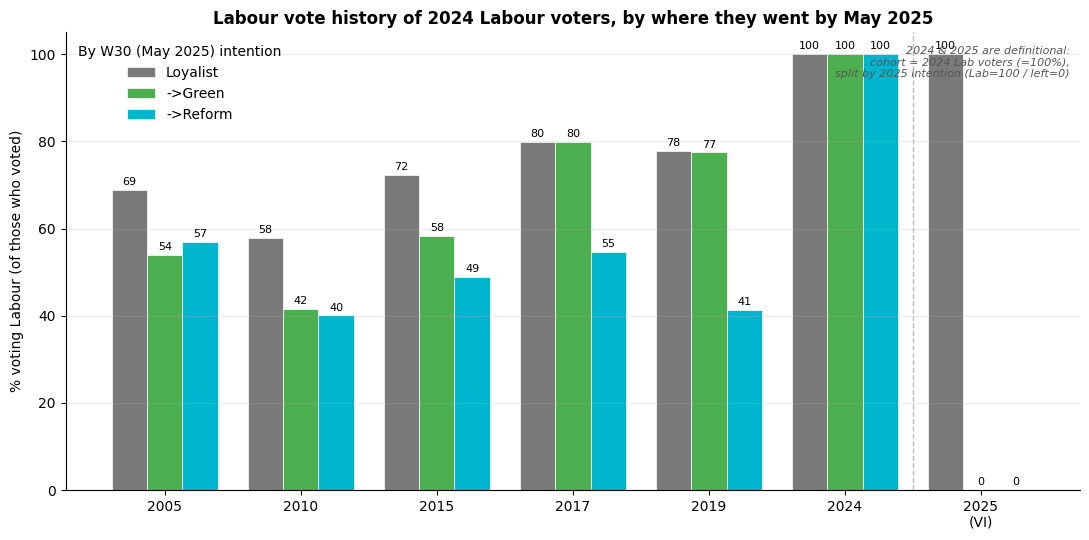

In [14]:
# 4c. Bar chart of the Labour vote history
fig, ax = plt.subplots(figsize=(11, 5.5))
series = ["Loyalist", "->Green", "->Reform"]
colors = {"Loyalist": "#7a7a7a", "->Green": "#4caf50", "->Reform": "#00b6cf"}
x = np.arange(len(period)); bw = 0.26
for i, g in enumerate(series):
    vals = [hist[g][y] for y in period]
    bars = ax.bar(x + (i - 1) * bw, vals, bw, label=g, color=colors[g], edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([str(y) for y in ELECTIONS] + ["2025\n(VI)"])
ax.set_ylabel("% voting Labour (of those who voted)"); ax.set_ylim(0, 105)
ax.set_title("Labour vote history of 2024 Labour voters, by where they went by May 2025",
             fontsize=12, fontweight="bold")
ax.legend(title="By W30 (May 2025) intention", frameon=False)
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.25)
ax.axvline(len(ELECTIONS) - 0.5, color="#bbb", linestyle="--", linewidth=1)
ax.annotate("2024 & 2025 are definitional:\ncohort = 2024 Lab voters (=100%),\nsplit by 2025 intention (Lab=100 / left=0)",
            xy=(0.99, 0.97), xycoords="axes fraction", ha="right", va="top", fontsize=8, color="#555", style="italic")
fig.tight_layout()
fig.savefig(OUT_DIR / "switcher_labour_vote_history.png", dpi=150)
plt.show()
